<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter3/3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 선형회귀

## k 최근접 이웃의 한계

In [1]:
#데이터
import numpy as np

perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [2]:
#훈련세트 테스트 세트 나누고 변환
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)

train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [3]:
# k-최근접 이웃 회귀 모델을 훈련
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

In [4]:
#길이가 50cm인 농어 예측. 실제로는 1.5kg
print(knr.predict([[50]]))

[1033.33333333]


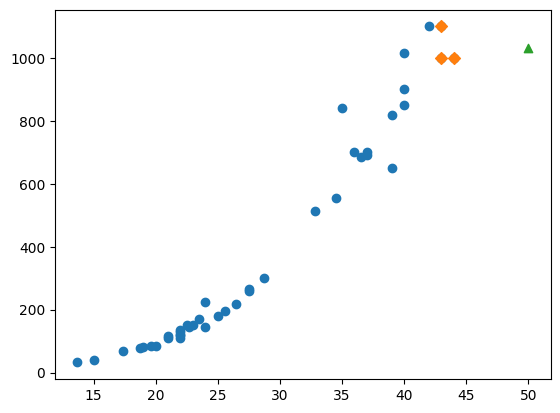

In [6]:
#시각화를 위해 산점도 그리기
import matplotlib.pyplot as plt

distance, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

plt.scatter(50, 1033, marker='^')
plt.show()

길이가 50인 농어 주변 3개의 평균을 내다보니 1033으로 잡힌것.


In [7]:
#값이 크면 전부 같은 값으로 나옴.
print(np.mean(train_target[indexes]))
print(knr.predict([[100]]))

1033.3333333333333
[1033.33333333]


## 선형회귀

널리 사용되는 회귀 알고리즘.

In [9]:
#선형회귀 모델 훈련
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)

print(lr.predict([[50]]))

[1241.83860323]


In [10]:
#선형회귀 직선 ax + b에서 a와 b
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535477


coef와 intercept 를 머신러닝 알고리즘이 찾은 값이라는 의미로 모델 파라미터라고 부름. 이 최적의 모델 파라미터를 찾아야함. 이를 모델 기반 학습이라고 부름.

앞서 사용한 k-최근접 알고리즘은 모델 파라미터가 없고 훈련세트를 저장하는 것이 훈련의 전부이다. 이를 사례 기반 학습이라 부름.

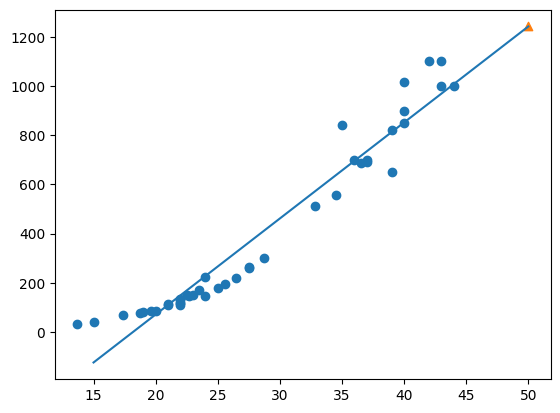

In [12]:
#학습한 직선 그리기
plt.scatter(train_input, train_target)

#15에서 50까지 1차 방성식 그래프를 그림
plt.plot([15, 50], [15*lr.coef_ + lr.intercept_, 50*lr.coef_ + lr.intercept_])

plt.scatter(50, 1241.8, marker='^')
plt.show()

In [13]:
#과대적합
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.939846333997604
0.8247503123313558


## 다항회귀
농어 산점도가 약간 구부러진 2차함수 모양이므로 다항회귀로 구해보기
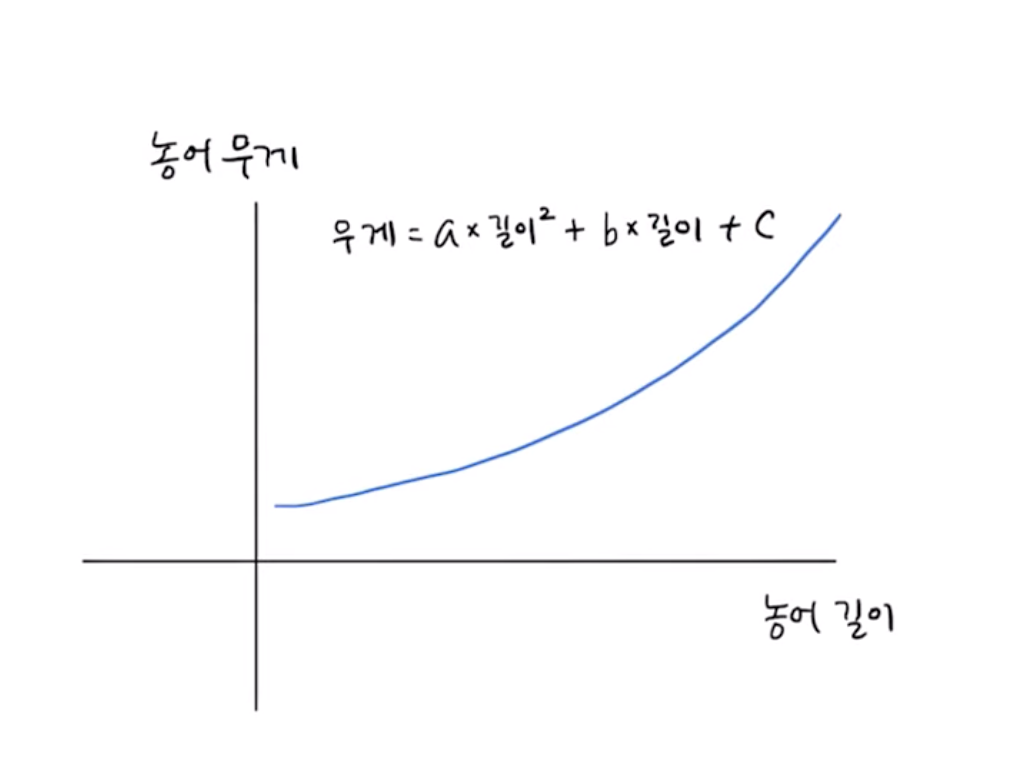

In [16]:
#변수인 길이의 제곱을 만들기 위해서는 앞 챕터에서 배운 column_stack이 유용
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

print(train_poly, test_poly)

[[ 384.16   19.6 ]
 [ 484.     22.  ]
 [ 349.69   18.7 ]
 [ 302.76   17.4 ]
 [1296.     36.  ]
 [ 625.     25.  ]
 [1600.     40.  ]
 [1521.     39.  ]
 [1849.     43.  ]
 [ 484.     22.  ]
 [ 400.     20.  ]
 [ 484.     22.  ]
 [ 576.     24.  ]
 [ 756.25   27.5 ]
 [1849.     43.  ]
 [1600.     40.  ]
 [ 576.     24.  ]
 [ 441.     21.  ]
 [ 756.25   27.5 ]
 [1600.     40.  ]
 [1075.84   32.8 ]
 [ 702.25   26.5 ]
 [1332.25   36.5 ]
 [ 187.69   13.7 ]
 [ 515.29   22.7 ]
 [ 225.     15.  ]
 [1369.     37.  ]
 [1225.     35.  ]
 [ 823.69   28.7 ]
 [ 552.25   23.5 ]
 [1521.     39.  ]
 [ 441.     21.  ]
 [ 529.     23.  ]
 [ 484.     22.  ]
 [1936.     44.  ]
 [ 506.25   22.5 ]
 [ 361.     19.  ]
 [1369.     37.  ]
 [ 484.     22.  ]
 [ 655.36   25.6 ]
 [1764.     42.  ]
 [1190.25   34.5 ]] [[  70.56    8.4 ]
 [ 324.     18.  ]
 [ 756.25   27.5 ]
 [ 453.69   21.3 ]
 [ 506.25   22.5 ]
 [1600.     40.  ]
 [ 900.     30.  ]
 [ 605.16   24.6 ]
 [1521.     39.  ]
 [ 441.     21.  ]
 [1892.25  

이렇게 새로 만든 train_poly로 다시 훈련.
주목할 점은 2차 방정식 그래프를 찾기 위해 훈련 세트에 제곱항을 추가했지만 타깃값은 그대로 사용.
목표하는 값은 어떤 그래프를 훈련하든 바꿀 필요가 없다.

In [17]:
#다항 회귀 모델 훈련
lr = LinearRegression()
lr.fit(train_poly, train_target)

print(lr.predict([[50**2, 50]]))
print(lr.coef_, lr.intercept_)

[1573.98423528]
[  1.01433211 -21.55792498] 116.0502107827827


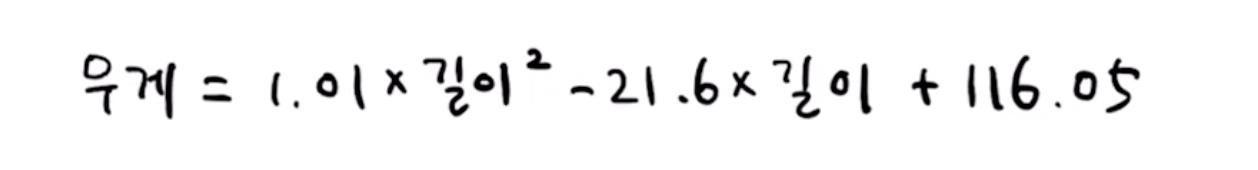

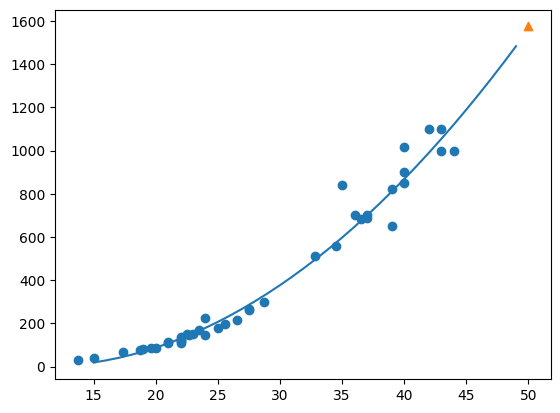

In [21]:
#학습한 직선 그리기(짧은 직선을 이어서 그려서 곡선처럼 표현하기)
point = np.arange(15, 50)
#훈련세트 산점도
plt.scatter(train_input, train_target)

#15에서 49까지 2차 방정식 그래프
plt.plot(point, 1.01*point**2 - 21.6*point + 116.05)

plt.scatter([50], [ 1574], marker = '^')
plt.show()

In [22]:
#훈련세트와 테스트세트 결정계수
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9706807451768623
0.9775935108325122


점수가 높아졌지만 여전히 과소적합이 남아있음.
더욱 발전시킬 여지가 남아있음.

k-최근접 이웃 알고리즘을 사용했을때는 이웃으로 평균을 구하니 훈련세트 밖을 예상할수 없음.
-> 이를 해결하기 위해 선형회귀 사용. 모델을 훈련하고 훈련세트 밖의 샘플을 예측할 수 있었음
-> 모델이 단순하여 오류가 있을 수 있음. 이를 해결하기 위해 다항회귀를 사용하여 다시 훈련시켰음.
-> 여전히 과소적합이 존재하므로 더 복잡한 모델을 이용하여 발전시킬 여지가 있음.